![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


 The manual process mainly relies on humans which is subjective to human judgement. Different loan approvers may have different judgement. Approving a loan that is defaulted is more costly per the information provided as this will cost the business $50,000 for a defaulted loan hence it is more expensive to have False postives.We will focus on precision because if  precision is low, the model is approving many risky applicants. I chose classification approach as this will help me classify if an applicant will default the loan or not. Also, this will help me evaluate the model using metrics like precision and recall. 

 I will use both precision and recall metrics to evaluate the model but mainly focus on having a higher precision.This is because  false positive errors are significantly more costly than false negative errors. False postive estimated loss of $50,000 while false negatives has an estimated $8,000 in profi loss. 

 Also, false negatives may impact the customers as this may result to them losing faith in the company as they were incorrectly denied a loan. 



## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier





In [4]:
# EDA Code Here - Create New Cells As Needed
data = pd.read_csv("financial_loan_data.csv")
pd.set_option('display.max_columns', None)
data.head(10)

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
5,37,"$178,310.00",626,Self-Employed,Master,16,15433,72,Married,0,Rent,732,0.102211,5,1,0.259366,No,Debt Consolidation,1,16,19,2118.0,1223,67914,40843,14859.166667,0.756079,5,27071,0.217433,0.217601,385.577074,0.075211,1,44.0
6,58,"$51,250.00",564,Employed,High School,39,12741,48,Married,0,Rent,337,0.367380,6,1,0.127473,No,Other,0,21,18,5161.0,1735,65624,43894,4270.833333,0.884275,5,21730,0.225741,0.205271,391.300352,0.170529,0,50.0
7,49,"$97,345.00",516,Employed,High School,23,19634,12,Divorced,5,Mortgage,288,0.209768,5,0,0.395568,No,Other,0,19,11,781.0,74,50177,11556,8112.083333,0.933492,5,38621,0.226634,0.209113,1827.360055,0.260767,1,42.4
8,34,"$116,841.00",603,Employed,Bachelor,12,55353,60,Divorced,5,Own,638,0.192701,3,0,0.313233,Yes,Debt Consolidation,0,25,29,1157.0,708,29632,49940,9736.750000,0.728397,3,7711,0.258853,0.291539,1762.199026,0.246509,0,61.0
9,46,"$40,615.00",612,Employed,NaN,19,25443,12,Married,4,Other,704,0.512465,3,2,0.505148,No,Other,0,23,10,1028.0,446,129664,12852,3384.583333,0.615323,3,116812,0.184443,0.197271,2353.577424,0.903384,0,53.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [6]:
#Annual income is an object but it should be numeric, I have converted to float
data["AnnualIncome"].head(10)

data["AnnualIncome"] = (
    data["AnnualIncome"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
data["AnnualIncome"].dtype

dtype('float64')

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


In [8]:
#check for missing values
data.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

Three columns having missing values that is EducationLevel, MaritalStatus, SavingsAccountBalance. I will handle this on the preprocessing pipelines. 

In [9]:
#check for duplicates
data.duplicated().any()

np.False_

The data does  not have any duplicates

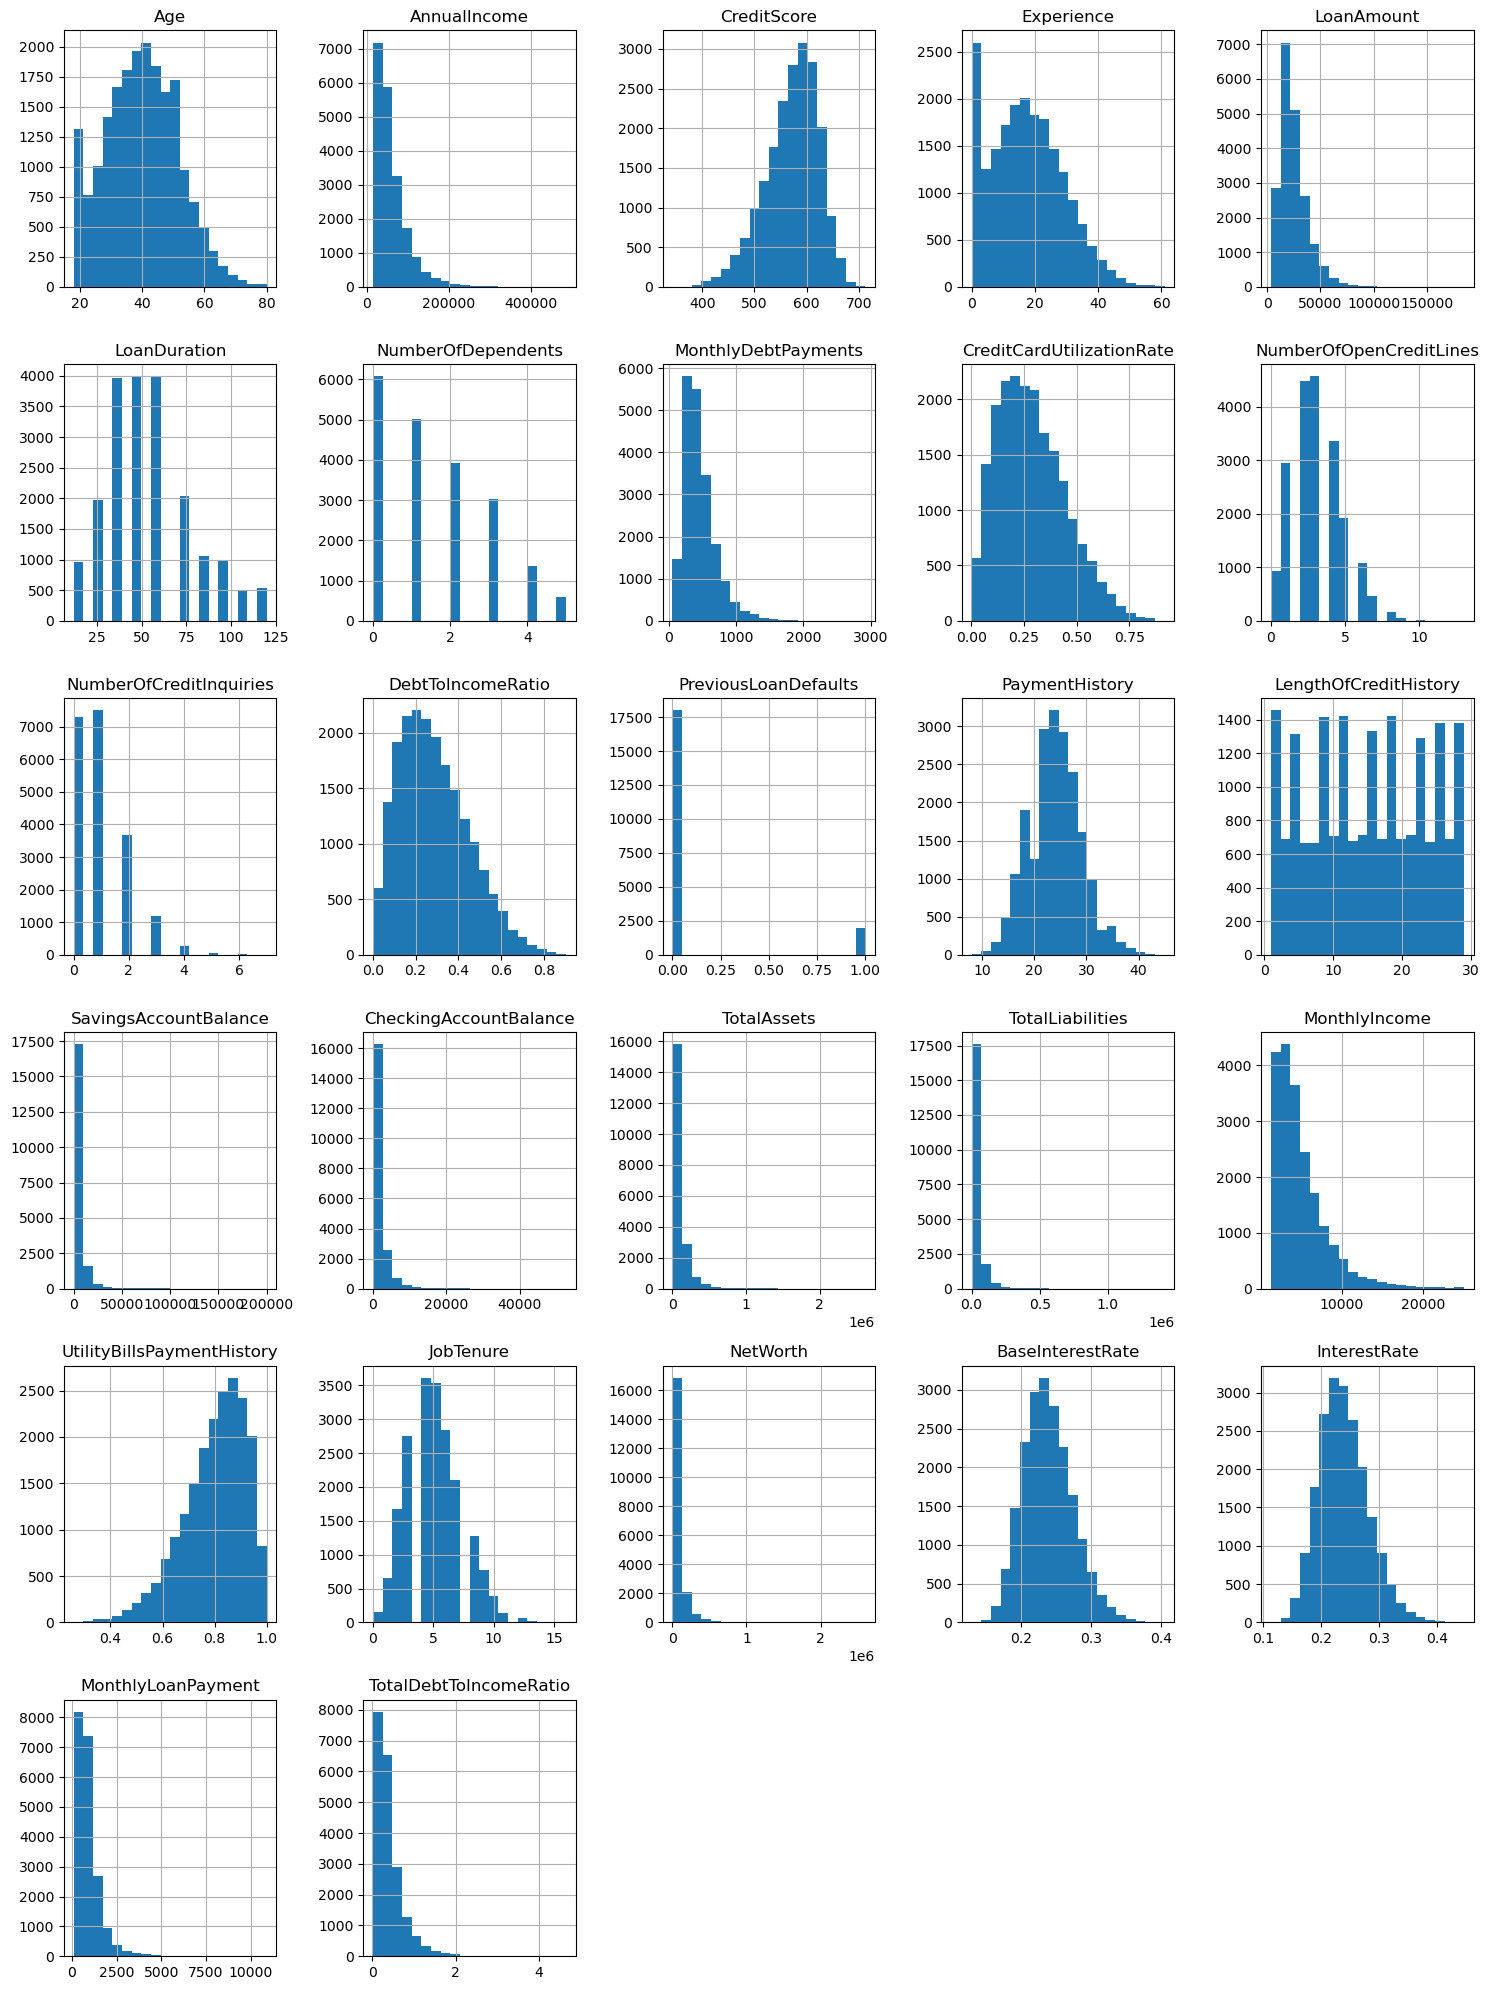

In [10]:
#Visualize numerical features
# I will drop the two target variable and visuliaze just the features
# Did not use a pairplot as it took so much timee to render
num_cols = data.select_dtypes(include=["int64", "float64"]).columns

num_cols = num_cols.drop(["LoanApproved", "RiskScore"])
data[num_cols].hist(figsize=(15, 20), bins=20)


plt.tight_layout()
plt.show()



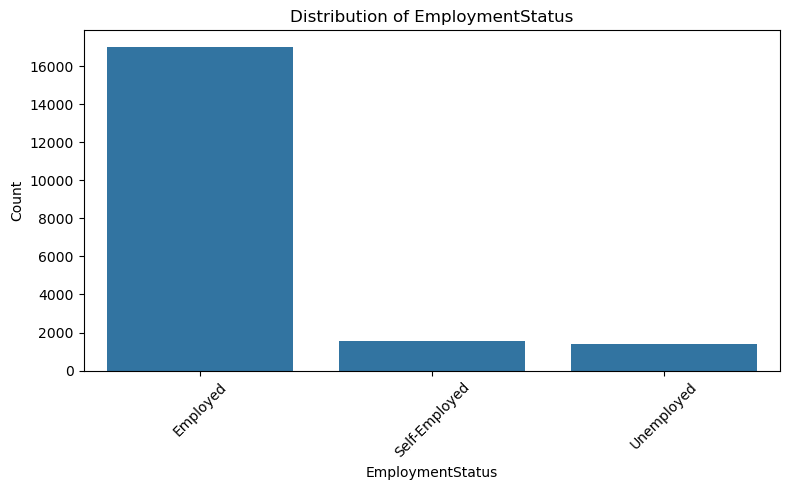

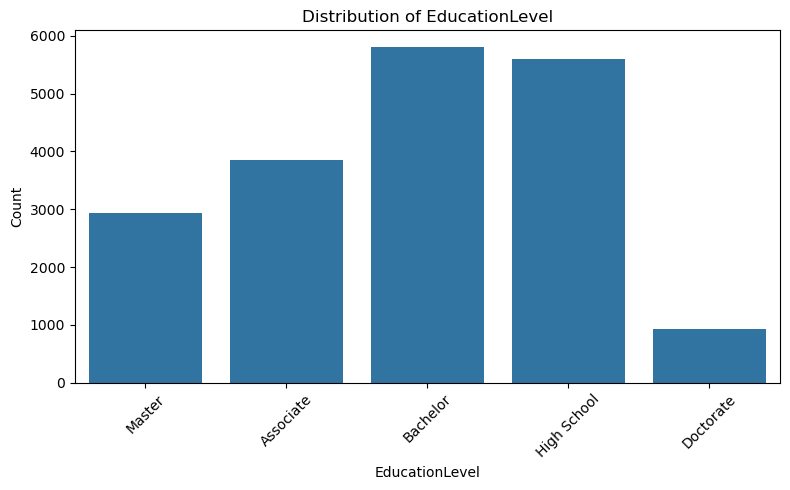

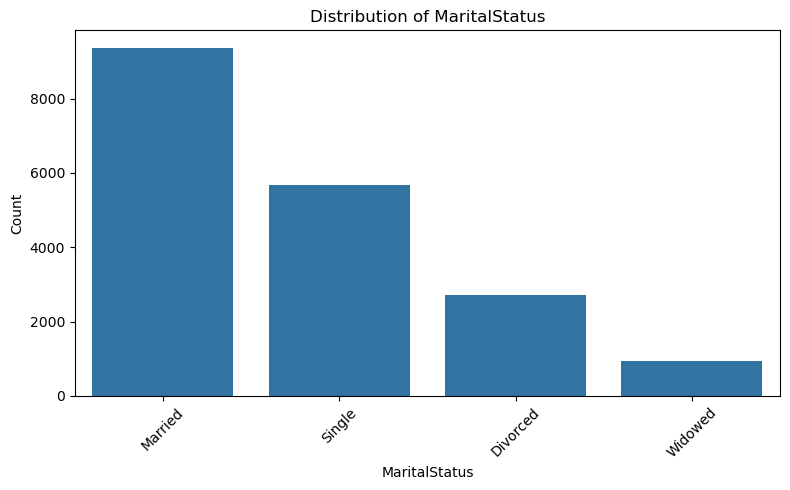

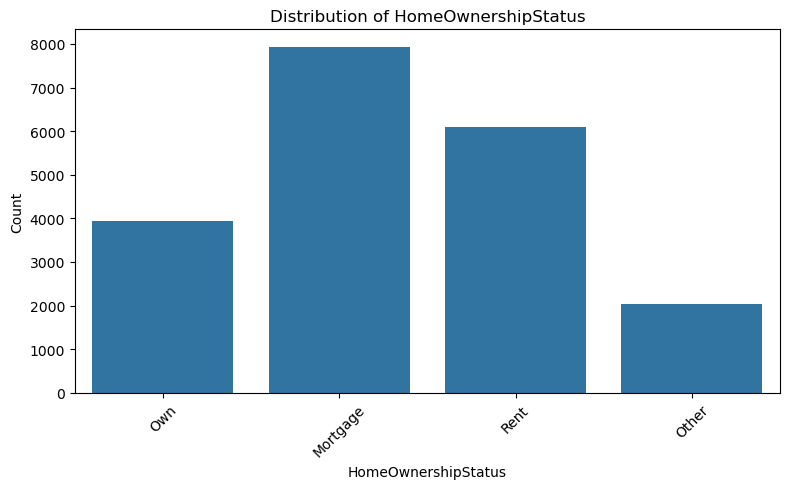

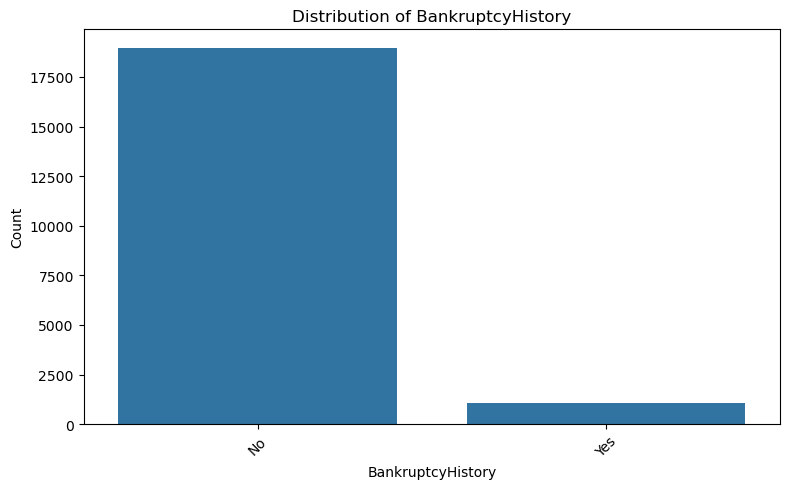

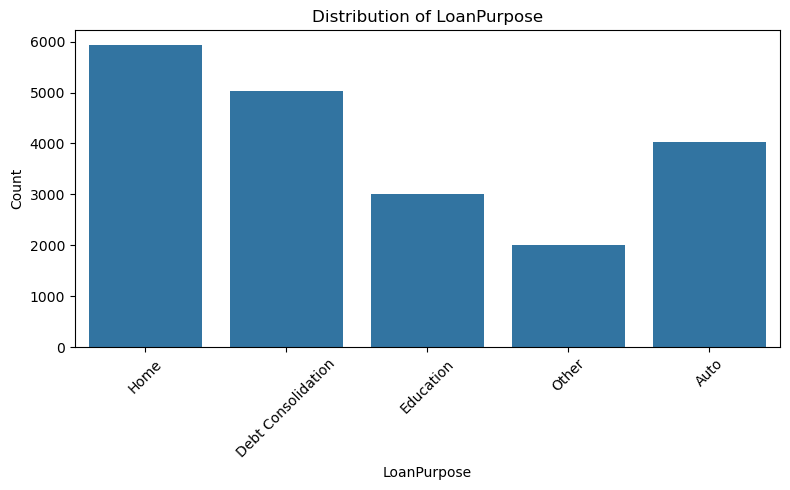

In [11]:
#Visualize Categorical columns
cat_cols = data.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(data=data, x=col)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

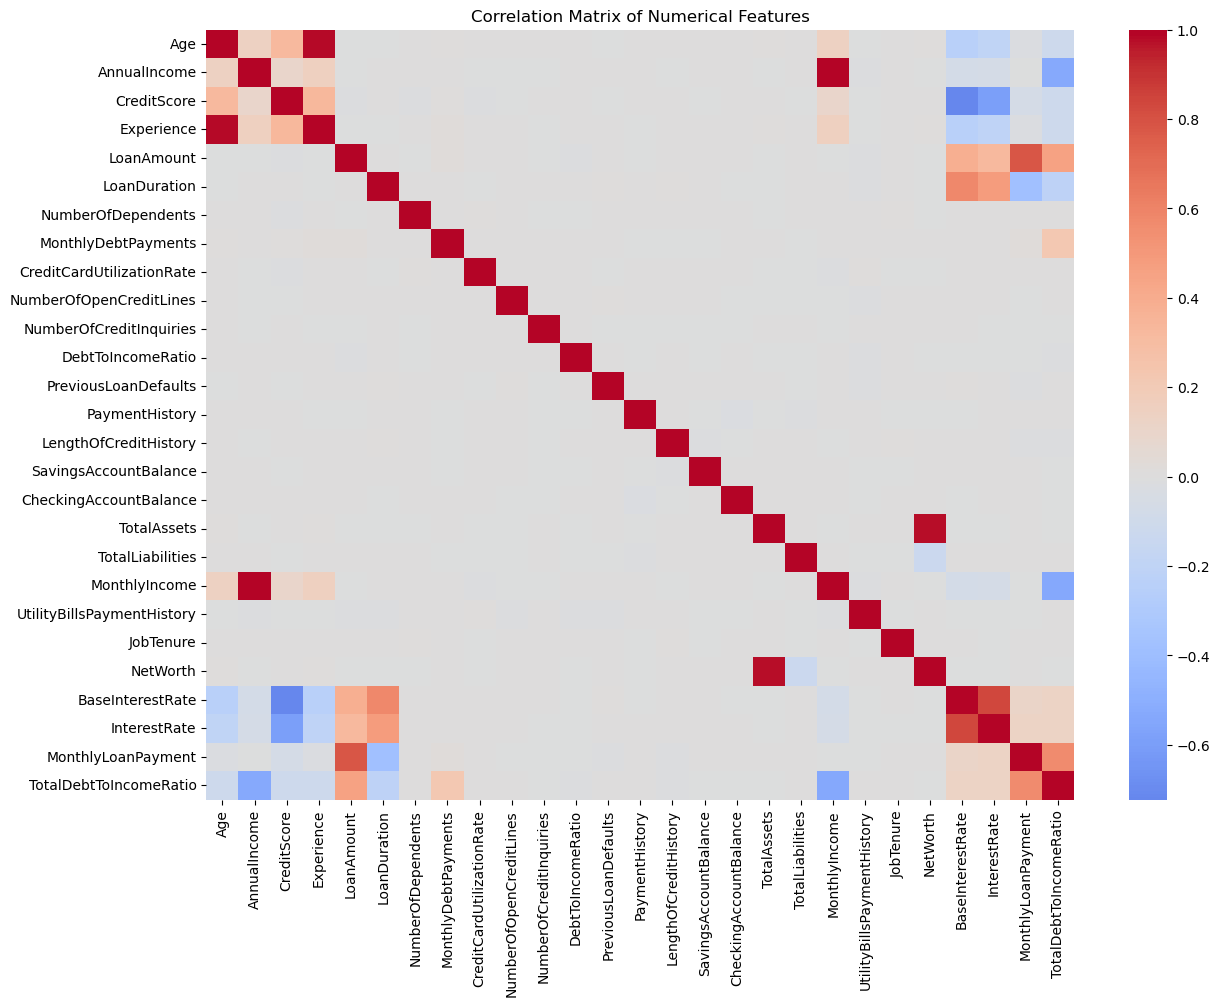

In [12]:
# Calculate correlations
corr = data[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Categorize features by type (numerical, categorical, ordinal)

In [13]:
numerical_features = [
    "Age",
    "AnnualIncome",
    "CreditScore",
    "Experience",
    "LoanAmount",
    "LoanDuration",
    "NumberOfDependents",
    "MonthlyDebtPayments",
    "CreditCardUtilizationRate",
    "NumberOfOpenCreditLines",
    "NumberOfCreditInquiries",
    "DebtToIncomeRatio",
    "PreviousLoanDefaults",
    "PaymentHistory",
    "LengthOfCreditHistory",
    "SavingsAccountBalance",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "MonthlyIncome",
    "UtilityBillsPaymentHistory",
    "JobTenure",
    "NetWorth",
    "BaseInterestRate",
    "InterestRate",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]
data[numerical_features].dtypes

Age                             int64
AnnualIncome                  float64
CreditScore                     int64
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
NumberOfDependents              int64
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBillsPaymentHistory    float64
JobTenure                       int64
NetWorth                        int64
BaseInterestRate              float64
InterestRate                  float64
MonthlyLoanPayment            float64
TotalDebtToI

In [14]:
categorical_features = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]
data[categorical_features].dtypes

EmploymentStatus       object
MaritalStatus          object
HomeOwnershipStatus    object
BankruptcyHistory      object
LoanPurpose            object
dtype: object

In [15]:
#checking what iscontained in educational level
data["EducationLevel"].unique()

array(['Master', 'Associate', 'Bachelor', 'High School', nan, 'Doctorate'],
      dtype=object)

In [16]:
ordinal_features = [
    "EducationLevel"
]

For preprocessing, numerical column SavingsAccountBalance I will impute with zero for Nan because if the value is missing the applicant does not have any savings. For caregorical columns Educational level and marital status that have missing values I will impute with unknown. 

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [17]:
#Numeric pipeline, I chose to impute with zero for the savingsaccount. Also I am scaling to have the numerical features on a uniform scale. 
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

In [18]:
#Categorical pipelne. I chose to impute with unknown the marital status as this data may not have been provided. Also I used onehotencoder to encode the categorical features. 
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [19]:
#Ordinal pipeline. I chose to impute the missing values of education level with unknown and used ordinal ecoding since the data is ordinal. 
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(
        categories=[["Unknown",
            "High School",
            "Associate",
            "Bachelor",
            "Master",
            "Doctorate"

        ]]
    ))
])

In [20]:
#Combine everything
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features),
    ("ord", ordinal_pipeline, ordinal_features)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'AnnualIncome', 'CreditScore',
                                  'Experience', 'LoanAmount', 'LoanDuration',
                                  'NumberOfDependents', 'MonthlyDebtPayments',
                                  'CreditCardUtilizationRate',
                                  'NumberOfOpenCreditLines',
                                  'NumberOfCreditInquiries',
                                  'Debt...
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['EmploymentStatus', 'MaritalStatus',
                                  'HomeOwnershipStatus', 'BankruptcyHistory',
                                  'LoanPurpose']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['Unknown',
                                                                              'High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'Doctorate']]))]),
                                 ['EducationLevel'])])

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [21]:
# Define the features and target variable
X = data.drop(columns=["LoanApproved", "RiskScore"])
y = data["LoanApproved"]

In [22]:
#Split the data, I chose to startify y as the target variable has class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Logistic Regression

In [23]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


### Decision Tree

In [69]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

### Random Forest


In [70]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

### Gradient Boosting

In [71]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

### XGBoost

In [72]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# Models Evaluation

In [73]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
    "XGBoost": xgb_pipeline
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall
    })
results_df = pd.DataFrame(results)

results_df    

,Model,Precision,Recall
0,Logistic Regression,0.935722,0.928870
1,Decision Tree,0.764948,0.776151
2,Random Forest,0.903529,0.803347
3,Gradient Boosting,0.912473,0.872385
4,XGBoost,0.920551,0.908996


Based on the above metrics, Logistic Regression is performing better than all the other models.

# Tune XGBoost

In [76]:
param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring="precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best parameters:")
print(grid_xgb.best_params_)

print("\nBest CV precision:")
print(grid_xgb.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

Best CV precision:
0.9215894011203943


In [77]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)

print("Tuned XGBoost Precision:", xgb_precision)
print("Tuned XGBoost Recall:", xgb_recall)

Tuned XGBoost Precision: 0.9289558665231432
Tuned XGBoost Recall: 0.9027196652719666


After tuning XGBoost, the Logistic Regression still performs better in terms of precision which is our primary metric. 

# Tune RandomForest

In [78]:
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid_rf,
    scoring="precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value=0,
                                                                                                        strategy='constant')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'AnnualIncome',
                                                                          'CreditScore',
                                                                          'Experience',
                                                                          'LoanAmount',
                                                                          'LoanDuration',
                                                                          'NumberOfDependents',
                                                                          'MonthlyDebtPayments',
                                                                          'CreditCardUtilizationRat...
                                                                                          OrdinalEncoder(categories=[['Unknown',
                                                                                                                      'High '
                                                                                                                      'School',
                                                                                                                      'Associate',
                                                                                                                      'Bachelor',
                                                                                                                      'Master',
                                                                                                                      'Doctorate']]))]),
                                                                         ['EducationLevel'])])),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20, None],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='precision', verbose=1)

In [79]:
print("Best parameters:")
print(grid_rf.best_params_)

print("\nBest CV precision:")
print(grid_rf.best_score_)

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV precision:
0.8914516535292687


In [80]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)

print("Tuned Random Forest Precision:", rf_precision)
print("Tuned Random Forest Recall:", rf_recall)

Tuned Random Forest Precision: 0.9035294117647059
Tuned Random Forest Recall: 0.803347280334728


Tuning Random Forest did not improve the primary metric, precision.

# Tune GradientBoost


In [82]:
param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

In [83]:
grid_gb = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=param_grid_gb,
    scoring="precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value=0,
                                                                                                        strategy='constant')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'AnnualIncome',
                                                                          'CreditScore',
                                                                          'Experience',
                                                                          'LoanAmount',
                                                                          'LoanDuration',
                                                                          'NumberOfDependents',
                                                                          'MonthlyDebtPayments',
                                                                          'CreditCardUtilizationRat...
                                                                                                        strategy='constant')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(categories=[['Unknown',
                                                                                                                      'High '
                                                                                                                      'School',
                                                                                                                      'Associate',
                                                                                                                      'Bachelor',
                                                                                                                      'Master',
                                                                                                                      'Doctorate']]))]),
                                                                         ['EducationLevel'])])),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [2, 3],
                         'model__n_estimators': [100, 200]},
             scoring='precision', verbose=1)

In [84]:
print("Best parameters:")
print(grid_gb.best_params_)

print("\nBest CV precision:")
print(grid_gb.best_score_)

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}

Best CV precision:
0.9236425696780606


In [85]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)

print("Tuned Gradient Boosting Precision:", gb_precision)
print("Tuned Gradient Boosting Recall:", gb_recall)

Tuned Gradient Boosting Precision: 0.9265033407572383
Tuned Gradient Boosting Recall: 0.8702928870292888


Tuning GradientBoost did not improve the primary metric, precision.

### Run Cross Validation on the Logistic Model

In [24]:
cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=["precision", "recall", "f1"],
    n_jobs=-1
)

print("Mean CV Precision:", cv_results["test_precision"].mean())
print("Mean CV Recall:", cv_results["test_recall"].mean())
print("Mean CV F1:", cv_results["test_f1"].mean())

Mean CV Precision: 0.9309399142622491
Mean CV Recall: 0.9231136433631045
Mean CV F1: 0.9269964634219955


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

### Evaluation of Final Model - Logistic Regression
Logistic Regression performed better than all the other models even after tuning. I chose to use this model because it is performing well and is interpretable. 

In [101]:
# Predict classes
y_pred_logistic = logistic_pipeline.predict(X_test)

# Predict probabilities
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

# Calculate metrics
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)


Precision: 0.9357218124341412
Recall: 0.9288702928870293
F1 Score: 0.9322834645669291
ROC-AUC: 0.9950729605946812


In [88]:
#confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

[[2978   66]
 [  93  863]]


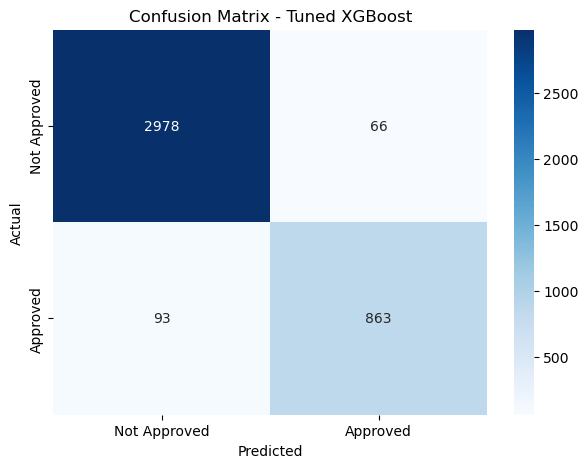

In [89]:
#Visualize Confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved", "Approved"],
    yticklabels=["Not Approved", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")

plt.show()

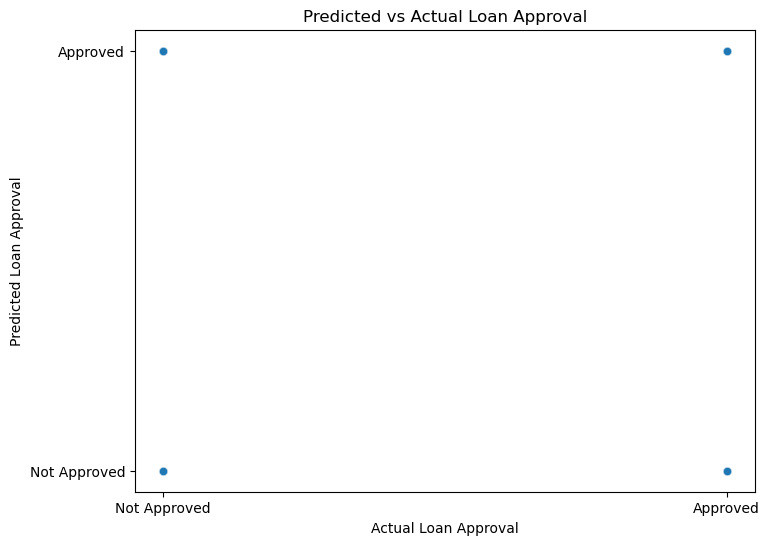

In [91]:
#Scatter plot of Predicted vs. Actual values
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_logistic,
    alpha=0.5
)

plt.xlabel("Actual Loan Approval")
plt.ylabel("Predicted Loan Approval")
plt.title("Predicted vs Actual Loan Approval")

plt.xticks([0, 1], ["Not Approved", "Approved"])
plt.yticks([0, 1], ["Not Approved", "Approved"])

plt.show()

###  Extract and interpret feature importance/significance:

In [98]:

preprocessor_fitted = logistic_pipeline.named_steps["preprocessor"]
model = logistic_pipeline.named_steps["model"]


feature_names = preprocessor_fitted.get_feature_names_out()


coefficients = model.coef_[0]

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

# Sort by absolute coefficient
feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
                             Feature  Coefficient  Absolute_Coefficient
26       num__TotalDebtToIncomeRatio    -8.170561              8.170561
24                 num__InterestRate    -5.222551              5.222551
19                num__MonthlyIncome     4.393507              4.393507
39         cat__BankruptcyHistory_No     3.208802              3.208802
40        cat__BankruptcyHistory_Yes    -3.119531              3.119531
22                     num__NetWorth     2.579170              2.579170
4                    num__LoanAmount    -2.162962              2.162962
2                   num__CreditScore    -2.099982              2.099982
29  cat__EmploymentStatus_Unemployed    -2.040015              2.040015
14        num__LengthOfCreditHistory     1.692182              1.692182


### Interpretation
TotalDebtToIncomeRatio has the strongest influence. higher TotalDebtToIncomeRatio lowers approval likelihood.
InterestRate also has a negative relationship with approval.
MonthlyIncome and NetWorth have positive relationships with approval. The higher they are the higher approval likelihood.
Bankruptcy history, LoanAmount, CreditScore, EmploymentStatus, and LengthOfCreditHistory also influence approval.


### Analyze performance across different data segments.

In [99]:
# Create evaluation dataframe
evaluation_df = X_test.copy()

evaluation_df["Actual"] = y_test.values
evaluation_df["Predicted"] = y_pred_xgb

# Check the employment groups
print(evaluation_df["EmploymentStatus"].value_counts())

EmploymentStatus
Employed         3402
Self-Employed     311
Unemployed        287
Name: count, dtype: int64


In [100]:

for status in evaluation_df["EmploymentStatus"].unique():
    
    group = evaluation_df[evaluation_df["EmploymentStatus"] == status]
    
    precision = precision_score(
        group["Actual"],
        group["Predicted"],
        zero_division=0
    )
    
    recall = recall_score(
        group["Actual"],
        group["Predicted"],
        zero_division=0
    )
    
    print(f"{status}:")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print()

Employed:
  Precision: 0.932
  Recall: 0.899

Unemployed:
  Precision: 0.868
  Recall: 0.920

Self-Employed:
  Precision: 0.938
  Recall: 0.927



The model performed well across all three employment groups with small variation.

### Identify potential biases or limitations.
The metrics are not equal among the different employemnt groups, the unemployed have a noticeably lower precision. Also, the sample size among the groups is not balanced as seen on the cells above, the self-employed and unemployed groups are much smaller. 

### Executive Summary
A classification approach was selected because the primary objective is to predict whether a loan application should be approved or not approved. Because the financial cost of approving a bad loan $50,000 is substantially higher than the cost of denying a creditworthy applicant $8,000, model precision was prioritized while recall was also considered important.

Five classification algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. I tuned 3 models that is Random Forest, Gradient Boosting, and XGBoost. 

From the model evaluation, I selected the Logistic Regression model as the final model because it achieved the highest precision among the models evaluated. The model achieved 93.57% precision, meaning most predicted approvals were correct and helping reduce costly false positives, which could cost $50,000 each. Its 92.89% recall means it correctly identifies most creditworthy applicants, while false negatives could result in approximately $8,000 in lost profit per applicant and also ruin the customers’ experience.

The coefficient analysis showed that TotalDebtToIncomeRatio had the strongest influence on loan approval, followed by InterestRate and MonthlyIncome. Higher debt-to-income ratios and interest rates were associated with a lower likelihood of approval, while higher monthly income was associated with a higher likelihood of approval.



### Recommendations for Implementation

The Logistic Regression model could be implemented as a decision-support tool to assist loan officers in assessing applications. Since false positives have a higher financial cost, the model's precision should continue to be monitored after implementation.

### Potential Improvements

Potential improvements include testing additional preprocessing and feature engineering techniques we can use PCA for dimensionality reduction. Also, the model could continue being evaluated on new data obtained to ensure that the performance remains constant.